In [ ]:
!pip install anthropic chromadb sentence-transformers PyPDF2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.4/469.4 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60

In [ ]:
import chromadb
from sentence_transformers import SentenceTransformer
import PyPDF2, re

embedder = SentenceTransformer('all-MiniLM-L6-v2')  # free, fast
client = chromadb.Client()
collection = client.create_collection("docs")

def chunk_text(text, chunk_size=500, overlap=50):
    words = text.split()
    chunks = []
    for i in range(0, len(words), chunk_size - overlap):
        chunks.append(" ".join(words[i:i+chunk_size]))
    return chunks

def ingest_pdf(path):
    reader = PyPDF2.PdfReader(path)
    text = " ".join(page.extract_text() for page in reader.pages)
    chunks = chunk_text(text)
    embeddings = embedder.encode(chunks).tolist()
    collection.add(
        documents=chunks,
        embeddings=embeddings,
        ids=[f"chunk_{i}" for i in range(len(chunks))]
    )
    print(f"Ingested {len(chunks)} chunks")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
from google.colab import files
uploaded = files.upload()  # opens a file picker

Saving RAG paper.pdf to RAG paper.pdf


In [ ]:
import anthropic
import json

from google.colab import userdata
api_key = userdata.get('API_KEY')
claude = anthropic.Anthropic(api_key=api_key)

def search_docs(query: str, n_results: int = 3) -> str:
    query_embedding = embedder.encode([query]).tolist()
    results = collection.query(query_embeddings=query_embedding, n_results=n_results)
    return "\n\n---\n\n".join(results['documents'][0])

# Define the search tool for Claude
tools = [{
    "name": "search_documents",
    "description": "Search the uploaded documents for relevant information. Use this whenever you need to answer a question about the documents.",
    "input_schema": {
        "type": "object",
        "properties": {
            "query": {"type": "string", "description": "Search query"}
        },
        "required": ["query"]
    }
}]

def run_agent(user_question: str):
    messages = [{"role": "user", "content": user_question}]
    system = "You are a helpful assistant. Use the search_documents tool to find relevant info before answering."

    while True:
        response = claude.messages.create(
            model="claude-haiku-4-5-20251001",
            max_tokens=1000,
            system=system,
            tools=tools,
            messages=messages
        )

        print("stop_reason:", response.stop_reason)
        print("content blocks:", [(b.type) for b in response.content])

        if response.stop_reason == "tool_use":
            tool_block = next(b for b in response.content if b.type == "tool_use")

            # Build messages manually and print to verify
            messages.append({
                "role": "assistant",
                "content": [
                    {"type": "tool_use", "id": tool_block.id, "name": tool_block.name, "input": tool_block.input}
                ]
            })
            messages.append({
                "role": "user",
                "content": [
                    {"type": "tool_result", "tool_use_id": tool_block.id, "content": search_docs(tool_block.input["query"])}
                ]
            })

            print("messages so far:", [{"role": m["role"], "content_types": [c["type"] for c in m["content"]] if isinstance(m["content"], list) else "string"} for m in messages])

        else:
            return next(b.text for b in response.content if hasattr(b, "text"))

# Run it!
ingest_pdf("RAG paper.pdf")
answer = run_agent("What are the main conclusions of this paper?")
print(answer)

Ingested 23 chunks
stop_reason: tool_use
content blocks: ['text', 'tool_use', 'tool_use']
messages so far: [{'role': 'user', 'content_types': 'string'}, {'role': 'assistant', 'content_types': ['tool_use']}, {'role': 'user', 'content_types': ['tool_result']}]
stop_reason: tool_use
content blocks: ['text', 'tool_use']
messages so far: [{'role': 'user', 'content_types': 'string'}, {'role': 'assistant', 'content_types': ['tool_use']}, {'role': 'user', 'content_types': ['tool_result']}, {'role': 'assistant', 'content_types': ['tool_use']}, {'role': 'user', 'content_types': ['tool_result']}]
stop_reason: end_turn
content blocks: ['text']
Based on the search results, here are the main conclusions of this paper about the RAG (Retrieval-Augmented Generation) model:

## Main Conclusions:

1. **Strong Performance Across Multiple Tasks**: RAG achieves state-of-the-art results on multiple tasks:
   - Sets new state-of-the-art on four open-domain question answering (QA) benchmarks
   - Achieves comp

In [ ]:
run_agent("What is the weather in Seattle today?")

stop_reason: end_turn
content blocks: ['text']


'I don\'t have access to real-time weather information or the internet. I can only search through documents that have been uploaded to me.\n\nTo find out the weather in Seattle today, I\'d recommend:\n- Checking a weather website like Weather.com, Weather.gov, or AccuWeather\n- Using a weather app on your phone\n- Searching "Seattle weather" in Google\n- Checking local Seattle news websites\n\nIs there anything else I can help you with, such as searching through documents you\'ve uploaded?'

In [ ]:
run_agent("What are the main conclusions? Quote the exact text you used to answer.")

stop_reason: tool_use
content blocks: ['text', 'tool_use']
messages so far: [{'role': 'user', 'content_types': 'string'}, {'role': 'assistant', 'content_types': ['tool_use']}, {'role': 'user', 'content_types': ['tool_result']}]
stop_reason: tool_use
content blocks: ['text', 'tool_use']
messages so far: [{'role': 'user', 'content_types': 'string'}, {'role': 'assistant', 'content_types': ['tool_use']}, {'role': 'user', 'content_types': ['tool_result']}, {'role': 'assistant', 'content_types': ['tool_use']}, {'role': 'user', 'content_types': ['tool_result']}]
stop_reason: end_turn
content blocks: ['text']


'Based on my search of the documents, here are the main conclusions from the paper on RAG (Retrieval-Augmented Generation):\n\n## Main Conclusions:\n\n1. **Overall Performance Achievement**: "RAG approaches state-of-the-art model performance, which is impressive given that (i) those models access gold passages with specific information required to generate the reference answer, (ii) many questions are unanswerable without the gold passages, and (iii) not all questions are answerable from Wikipedia alone."\n\n2. **Superior Factuality**: "Qualitatively, we find that RAG models hallucinate less and generate factually correct text more often than BART."\n\n3. **Human Evaluation Results**: "Evaluators indicated that BART was more factual than RAG in only 7.1% of cases, while RAG was more factual in 42.7% of cases, and both RAG and BART were factual in a further 17% of cases, clearly demonstrating the effectiveness of RAG on the task over a state-of-the-art generation model."\n\n4. **Diversi

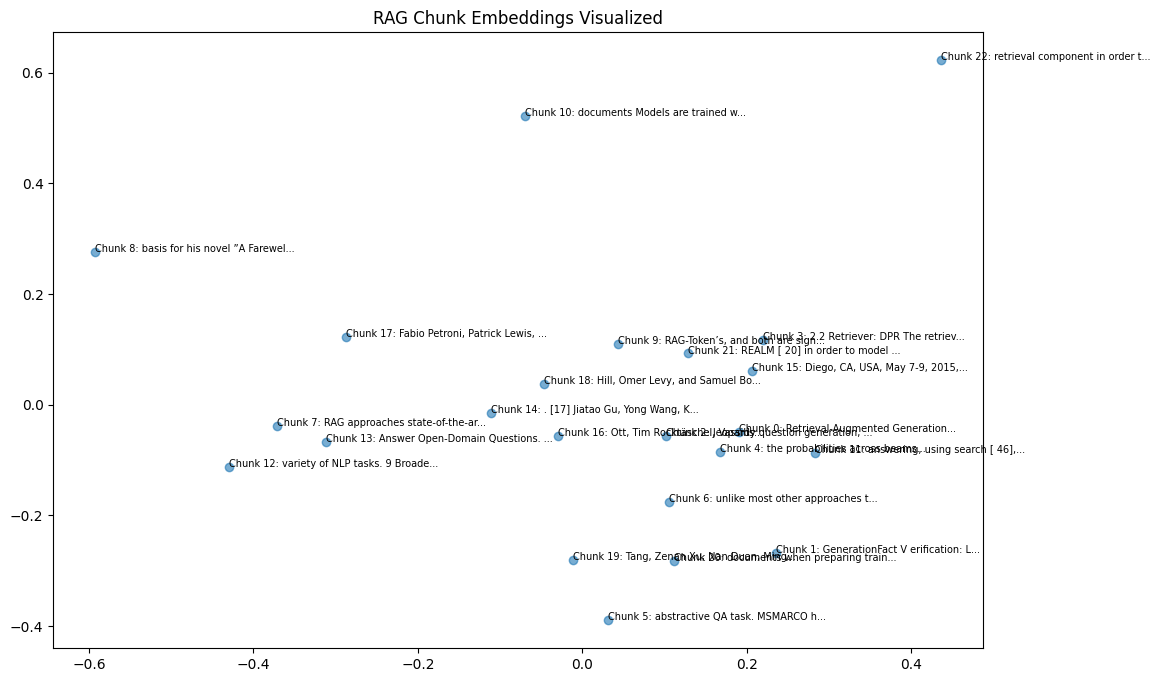

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# Get all embeddings from ChromaDB
results = collection.get(include=["embeddings", "documents"])
embeddings = np.array(results["embeddings"])
documents = results["documents"]

# Reduce to 2D for visualization
pca = PCA(n_components=2)
coords = pca.fit_transform(embeddings)

# Plot
plt.figure(figsize=(12, 8))
plt.scatter(coords[:, 0], coords[:, 1], alpha=0.6)
for i, doc in enumerate(documents):
    plt.annotate(f"Chunk {i}: {doc[:30]}...", (coords[i, 0], coords[i, 1]), fontsize=7)
plt.title("RAG Chunk Embeddings Visualized")
plt.show()